![](https://miro.medium.com/v2/resize:fit:720/format:webp/1*pwJx3R9vUsv6eHX8BjaKGw.png)

![](https://miro.medium.com/v2/resize:fit:720/format:webp/1*Yx1uv5W6feexSMWooiIAnA.png)

![](https://miro.medium.com/v2/resize:fit:720/format:webp/1*atwCMaAbIFP3iN3nyoV-pg.png)

**Generative AI vs. Agentic AI:** Traditional Generative AI chatbots (like standard ChatGPT) are reactive; they only answer the specific questions asked at each step. In contrast, Agentic AI is proactive and autonomous. 

For example, if you tell an Agentic AI you want to travel to Goa, it will independently figure out the dates, book transport, recommend hotels, and build an itinerary without you prompting it for each individual step.

![image.png](https://miro.medium.com/v2/resize:fit:1400/format:webp/1*WqizWv0xCY9zu6TRGPzaGA.png)

## The 6 Key Characteristics of Agentic AI
![](https://miro.medium.com/v2/resize:fit:720/format:webp/1*DbkKMzizfFr50ok4xrznwQ.png)

https://shahil04.medium.com/agentic-ai-using-langgraph-class-0-2-0f795330bdb3 

### The 5 Core Components of an Agentic AI System
Almost every high-level Agentic AI application is built using these five core components:
![](https://miro.medium.com/v2/resize:fit:720/format:webp/1*-cA7rxmECWLCaGT6FPHPhg.png)

1. Brain (The LLM) For LLM-based agents, the Large Language Model acts as the brain. 
2. Orchestrator The Orchestrator acts like the nervous system or project manager. While the Brain makes the plan, the Orchestrator actually executes it.  frameworks like LangGraph, CrewAI, or AutoGen
3. Tools Tools are the “hands and legs” that allow the agent to interact with the external world. Examples include APIs (like LinkedIn or Google Calendar), databases, email clients, and RAG-based internal knowledge bases.

4. Memory Memory tracks the state of the agent’s operations and context.(short term memory, long-term memory)
5. Supervisor This component implements the “Human-in-the-loop” concept. The Supervisor alerts the human when high-risk actions require approval, enforces system guardrails, and escalates edge cases 

## which one use for create a agentic ai 
 1. LangChain Vs LangGraph | 

 ![](https://miro.medium.com/v2/resize:fit:720/format:webp/1*Kykp2-hUs7EIFNy7mVuuMQ.png)

 2. Workflows vs. Agentic Systems
![](https://miro.medium.com/v2/resize:fit:640/format:webp/1*-GxtFx39Q5y7dnaXdBZkpw.png)

#### The 7 Challenges of LangChain (And How LangGraph Solves Them)
1. Challenge 1: Control Flow Complexity (Non-Linearity)
- LangGraph Solution: LangGraph represents workflows as Graphs.
2. Challenge 2: State Handling (“State” — a collection of data points whose values evolve over time.) LangChain is inherently stateless.
- LangGraph Solution: LangGraph is inherently stateful. You create a state object (like a Pydantic model or Typed Dictionary) that is accessible and mutable by every single node in the graph.

3. Challenge 3: Event-Driven Execution(LangChain is designed for sequential execution; )
- LangGraph Solution: LangGraph supports event-driven execution using “checkpointers”. It can save the current state, pause the workflow completely, and resume from the exact same node
4. Challenge 4: Fault Tolerance (Long-running workflows (which can take days or months) are prone to crashing in langchain.)
- LangGraph Solution: LangGraph offers built-in fault tolerance. For small faults, it supports automated retry logic. For big faults (like server crashes), it uses its checkpointers to perform “recovery,”
5. Challenge 5: Human-in-the-Loop (HITL) In LangChain, pausing a script to wait 24 hours for a manager’s input will consume computing resources and risk crashing the script.
- LangGraph Solution: Human-in-the-loop is a first-class citizen in LangGraph. It pauses execution indefinitely (for minutes, hours, or days) by saving the state, and seamlessly resumes once the human provides input.
6. Challenge 6: Nested Workflows (Subgraphs)
- LangGraph allows you to place an entire graph inside a single node of a larger graph. This is called a Subgraph. This is impossible in LangChain.
7. Challenge 7: Observability --> Monitoring and debugging a live AI system is critical. While LangChain integrates with LangSmith for tracking, it can only track LangChain components. It cannot track the custom Python “glue code” (like while loops)
- LangGraph Solution: Because you write zero “glue code” and everything is a node or an edge, LangGraph integrates perfectly with LangSmith/ Langfuse . It records a complete chronological timeline of every state change, message exchange, and human approval.

![](https://miro.medium.com/v2/resize:fit:720/format:webp/1*MsmdMNbX0kejaY-1l2aPXg.png)

![](https://miro.medium.com/v2/resize:fit:720/format:webp/1*coN7NhruXoGzpLyfNoLpJw.png)

![](https://miro.medium.com/v2/resize:fit:720/format:webp/1*50y2W62i2YCTR8mSSgbGjg.png)

Conclusion: Should You Abandon LangChain?
No. LangGraph is fundamentally an orchestration framework built on top of LangChain.

Use LangChain for its components (Models, Prompts, Retrievers, Output Parsers) and for simple, linear workflows.
Use LangGraph when you need to act as a “flowchart engine” to orchestrate those components into complex, stateful, multi-step, event-driven, or multi-agent workflows. Both tools will be used hand-in-hand to build industry-grade Agentic AI.

In [ ]:
!pip install langgraph

In [2]:
import langgraph

### LangGraph Core Concepts

https://shahil04.medium.com/langgraph-core-concepts-agentic-ai-using-langgraph-class-4-a1fd0a043b04

#### Graphs, Nodes, and Edges (The Core Structure)
![](https://miro.medium.com/v2/resize:fit:720/format:webp/1*nI369Wp558rpjHP3hTCR9g.png)

- State = data
- Node = work
- Edge = control flow
- Conditional edge = decision
- Reducer = state update/merge logic
- Checkpoint = persistence

### use the Langgraph component to create a BMI Calculator

#### 1. State
 State is the shared data of your workflow.


In [4]:
from typing import TypedDict

# define state
class BMIState(TypedDict):

    weight_kg: float
    height_m: float
    bmi: float
    category: str

### 2. Nodes -->
A node is a Python function that performs some work.

In [5]:
# Node 1  --> for calculate the bmi formula
def calculate_bmi(state: BMIState) -> BMIState:

    weight = state['weight_kg']
    height = state['height_m']

    bmi = weight/(height**2)

    state['bmi'] = round(bmi, 2)
    return state

A node receives the current state and returns updates to the state.

State → Node → State

In [6]:
# node 2 --> create a fuctions to make the label of bmi
def label_bmi(state: BMIState) -> BMIState:
    bmi = state['bmi']

    if bmi < 18.5:
        state["category"] = "Underweight"
    elif 18.5 <= bmi < 25:
        state["category"] = "Normal"
    elif 25 <= bmi < 30:
        state["category"] = "Overweight"
    else:
        state["category"] = "Obese"

    return state

### 3. StateGraph
StateGraph is used to create the graph.

In [7]:
# define your graph
graph = StateGraph(BMIState)

### Then add nodes and edges:
### 4. Edges
An edge determines which node runs next.

e.g: graph.add_edge("calculate_bmi", "label_bmi")

### 5. START and END
- START represents where the graph begins.
- END represents where the graph finishes.
### 6. . Compile
Before running the graph, compile it:
### 7. RUN/ Invoke
run the ai


In [8]:
from langgraph.graph import StateGraph, START, END
# define your graph
graph = StateGraph(BMIState)

# add nodes to your graph
graph.add_node('calculate_bmi', calculate_bmi)
graph.add_node('label_bmi', label_bmi)

# add edges to your graph
graph.add_edge(START, 'calculate_bmi')
graph.add_edge('calculate_bmi', 'label_bmi')
graph.add_edge('label_bmi', END)

# compile the graph
workflow = graph.compile()

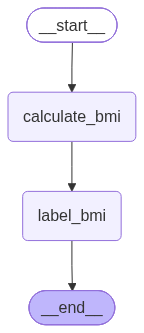

In [9]:
workflow

In [10]:
# execute the graph
intial_state = {'weight_kg':80, 'height_m':1.73}

final_state = workflow.invoke(intial_state)

print(final_state)

{'weight_kg': 80, 'height_m': 1.73, 'bmi': 26.73, 'category': 'Overweight'}


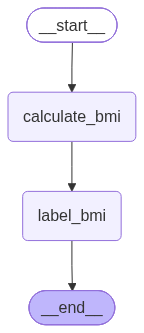

In [11]:
# create a visualizations of chatbot workflow 
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

## Now create a basic LLM workflow using LangGraph

In [ ]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from typing import TypedDict
from dotenv import load_dotenv
load_dotenv()
model = ChatOpenAI()

In [ ]:
# create a state

class LLMState(TypedDict):

    question: str
    answer: str
# =========================================
# define node
def llm_qa(state: LLMState) -> LLMState:

    # extract the question from state
    question = state['question']

    # form a prompt
    prompt = f'Answer the following question {question}'

    # ask that question to the LLM
    answer = model.invoke(prompt).content

    # update the answer in the state
    state['answer'] = answer

    return state

# ================================================
# create our graph

graph = StateGraph(LLMState)

# add nodes
graph.add_node('llm_qa', llm_qa)

# add edges
graph.add_edge(START, 'llm_qa')
graph.add_edge('llm_qa', END)

# compile
workflow = graph.compile()

In [ ]:
# execute
intial_state = {'question': 'How far is moon from the earth?'}

final_state = workflow.invoke(intial_state)

print(final_state['answer'])

In [ ]:
model.invoke('How far is moon from the earth?').content

In [ ]:
# use any AI LLM
from dotenv import load_dotenv
load_dotenv()

from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4o",temperature=0.7)
## gemini
from langchain_google_genai import ChatGoogleGenerativeAI
llm2 = ChatGoogleGenerativeAI(model='gemini-3.5-flash')

result = model.invoke('What is the capital of India')
print(result.content)
# pip install langchain-groq
from langchain_groq import ChatGroq

llm3 = ChatGroq(model="llama-3.3-70b-versatile",temperature=0.7)

# 3. Create a automations Blog writing AI.
- (Prompt Chaining) 

TASK 1. create a Blog outline(), 2. then create a blog.

In [ ]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from typing import TypedDict
from dotenv import load_dotenv
load_dotenv()
model = ChatOpenAI()

In [ ]:
class BlogState(TypedDict):

    title: str
    outline: str
    content: str
# ==============================================================
def create_outline(state: BlogState) -> BlogState:

    # fetch title
    title = state['title']

    # call llm gen outline
    prompt = f'Generate a detailed outline for a blog on the topic - {title}'
    outline = model.invoke(prompt).content

    # update state
    state['outline'] = outline

    return state

# ==================================================================
def create_blog(state: BlogState) -> BlogState:

    title = state['title']
    outline = state['outline']

    prompt = f'Write a detailed blog on the title - {title} using the follwing outline \n {outline}'

    content = model.invoke(prompt).content

    state['content'] = content

    return state

# =============================================================
graph = StateGraph(BlogState)

# nodes
graph.add_node('create_outline', create_outline)
graph.add_node('create_blog', create_blog)

# edges
graph.add_edge(START, 'create_outline')
graph.add_edge('create_outline', 'create_blog')
graph.add_edge('create_blog', END)

workflow = graph.compile()


In [ ]:
# RUN / Invoke 
intial_state = {'title': 'Rise of AI in India'}

final_state = workflow.invoke(intial_state)

print(final_state)

In [ ]:
# if only see the outline
print(final_state['outline'])

In [ ]:
# if you need the final blog content
print(final_state['content'])

#### Some Langgraph keywords
1. A. Prompt Chaining --> Calling an LLM multiple times sequentially to break down a complex task into manageable sub-tasks.
2. B. Routing -->Analyzing an input task and deciding which specialized LLM or tool is best suited to execute it.
3. Parallelization -->Breaking a task into multiple sub-tasks that are executed simultaneously, and then aggregating their results.
4. D. Orchestrator-Worker -->  Similar to parallelization, but the sub-tasks are not predefined. An orchestrator dynamically assigns tasks to workers based on the specific input query.

5. E. Evaluator-Optimizer --> An iterative loop used for creative tasks where a perfect result is rarely achieved on the first try.
6. 5. Reducers --> Reducers define how updates from nodes are applied to the shared state (whether the new data should replace, add, or merge with existing data). 

![](https://miro.medium.com/v2/resize:fit:720/format:webp/1*ktxJNSZ2xJnzWEGHEhNtaw.png)
![](https://miro.medium.com/v2/resize:fit:640/format:webp/1*C4xFuBFU7PCUDHPq8PLM9A.png)

## TASK 
### Create a LangGraph workflow to create a cricket batsman boundry %, strike rate,Balls per boundary ,Boundary percent   


In [ ]:
class BatsmanState(TypedDict):
    # input variables
    runs: int
    balls: int
    fours: int
    sixes: int
    # calcuations and results variables
    sr: float
    bpb: float
    boundary_percent: float
    summary: str

Full code in Markdown Comment
<!-- 

class BatsmanState(TypedDict):

    runs: int
    balls: int
    fours: int
    sixes: int

    sr: float
    bpb: float
    boundary_percent: float
    summary: str

#=====================================================
def calculate_sr(state: BatsmanState):

    sr = (state['runs']/state['balls'])*100
    
    return {'sr': sr}

def calculate_bpb(state: BatsmanState):

    bpb = state['balls']/(state['fours'] + state['sixes'])

    return {'bpb': bpb}

def calculate_boundary_percent(state: BatsmanState):

    boundary_percent = (((state['fours'] * 4) + (state['sixes'] * 6))/state['runs'])*100

    return {'boundary_percent': boundary_percent}

def summary(state: BatsmanState):

    summary = f"""
Strike Rate - {state['sr']} \n
Balls per boundary - {state['bpb']} \n
Boundary percent - {state['boundary_percent']}
"""
    
    return {'summary': summary}
# ===============================================================
graph = StateGraph(BatsmanState)

graph.add_node('calculate_sr', calculate_sr)
graph.add_node('calculate_bpb', calculate_bpb)
graph.add_node('calculate_boundary_percent', calculate_boundary_percent)
graph.add_node('summary', summary)

# edges

graph.add_edge(START, 'calculate_sr')
graph.add_edge(START, 'calculate_bpb')
graph.add_edge(START, 'calculate_boundary_percent')

graph.add_edge('calculate_sr', 'summary')
graph.add_edge('calculate_bpb', 'summary')
graph.add_edge('calculate_boundary_percent', 'summary')

graph.add_edge('summary', END)

workflow = graph.compile()
#======================================================
workflow
# ============================================================
intial_state = {
    'runs': 100,
    'balls': 50,
    'fours': 6,
    'sixes': 4
}

workflow.invoke(intial_state)

 -->